<a href="https://colab.research.google.com/github/sandip-1996/PRML_exercise_code_example/blob/Probability-distribution-ch.-2/dirichlet_prior_multinomial_distribution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Observed counts: [7 6 7]


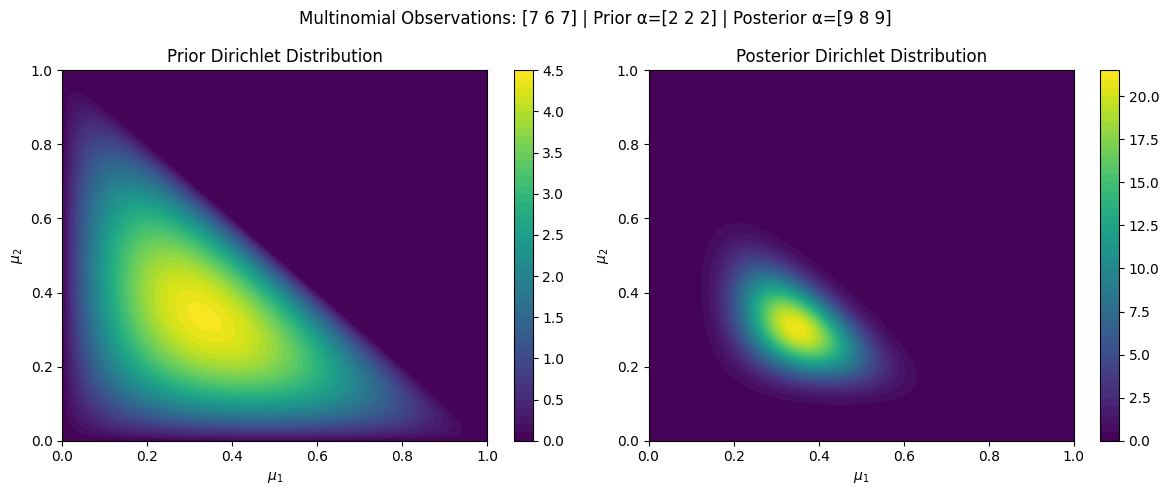

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import dirichlet, multinomial

# Step 1: Define prior (Dirichlet distribution parameters)
alpha = np.array([2, 2, 2])  # Prior (symmetric Dirichlet prior)
K = len(alpha)

# Step 2: Generate observed data (multinomial samples)
N = 20  # number of trials
true_probs = [0.5, 0.3, 0.2]  # true probabilities
data = multinomial.rvs(N, true_probs, size=1)[0]  # observed counts
print("Observed counts:", data)

# Step 3: Update posterior parameters
posterior_alpha = alpha + data

# Step 4: Plot prior and posterior Dirichlet distributions (for 3 variables)
def dirichlet_pdf_on_simplex(alpha, resolution=200):
    x = np.linspace(0, 1, resolution)
    y = np.linspace(0, 1, resolution)
    X, Y = np.meshgrid(x, y)
    Z = np.full_like(X, np.nan, dtype=float)
    for i in range(resolution):
        for j in range(resolution):
            if X[i, j] + Y[i, j] <= 1:  # only inside simplex
                z3 = 1 - X[i, j] - Y[i, j]
                if z3 >= 0:  # avoid negatives
                    Z[i, j] = dirichlet.pdf([X[i, j], Y[i, j], z3], alpha)
    return X, Y, Z

# Prior distribution
X, Y, Z_prior = dirichlet_pdf_on_simplex(alpha)

# Posterior distribution
_, _, Z_post = dirichlet_pdf_on_simplex(posterior_alpha)

# Step 5: Plot results
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Prior plot
cp = ax[0].contourf(X, Y, np.nan_to_num(Z_prior), levels=50, cmap="viridis")
ax[0].set_title("Prior Dirichlet Distribution")
ax[0].set_xlabel(r"$\mu_1$")
ax[0].set_ylabel(r"$\mu_2$")
fig.colorbar(cp, ax=ax[0])

# Posterior plot
cp = ax[1].contourf(X, Y, np.nan_to_num(Z_post), levels=50, cmap="viridis")
ax[1].set_title("Posterior Dirichlet Distribution")
ax[1].set_xlabel(r"$\mu_1$")
ax[1].set_ylabel(r"$\mu_2$")
fig.colorbar(cp, ax=ax[1])

plt.suptitle(f"Multinomial Observations: {data} | Prior α={alpha} | Posterior α={posterior_alpha}")
plt.tight_layout()
plt.show()
